In [ ]:
from typing import Dict, List, Union
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt
from matplotlib import rcParams 
from scipy.stats import norm

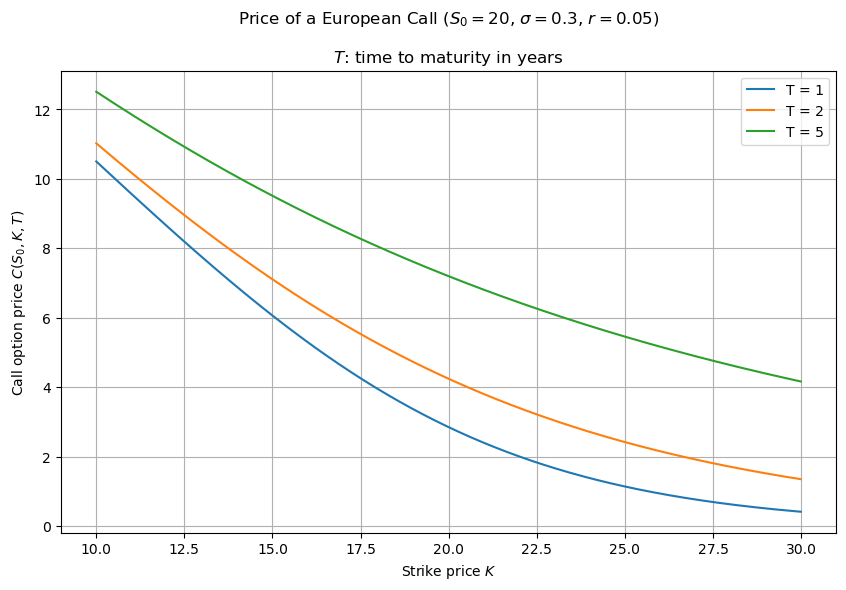

In [3]:
def black_scholes_eur_call(r: float, T: float, S0: float, sigma: float, K: Union[float, List[float], np.ndarray]) -> np.ndarray:
    # check conditions
    assert sigma > 0

    K = np.array([K]) if isinstance(K, float) else np.array(K)
    d1_vec = ( np.log( S0 / K ) + ( r + 0.5 * sigma**2 ) * T ) / ( sigma * T**0.5 )
    d2_vec = d1_vec - sigma * T**0.5
    N_d1_vec = norm.cdf(d1_vec)
    N_d2_vec = norm.cdf(d2_vec)
    call_price=N_d1_vec * S0 - K * np.exp((-1.0)*r*T) * N_d2_vec
    return call_price
def black_scholes_eur_call_greeks(r: float, T: float, S0: float, sigma: float, K: Union[float, List[float], np.ndarray]) -> np.ndarray:
    # check conditions
    assert sigma > 0

    K = np.array([K]) if isinstance(K, float) else np.array(K)
    d1_vec = ( np.log( S0 / K ) + ( r + 0.5 * sigma**2 ) * T ) / ( sigma * T**0.5 )
    d2_vec = d1_vec - sigma * T**0.5
    N_d1_vec = norm.cdf(d1_vec)
    N_d2_vec = norm.cdf(d2_vec)

    #greeks
    gamma=norm.pdf(d1_vec)*(1/(S0*sigma*np.sqrt(T)))
    vega= S0 * norm.pdf(d1_vec)*np.sqrt(T)
    theta=-S0*norm.pdf(d1_vec)*(sigma*2*np.sqrt(T))*-r*K*np.exp(-r*T)*norm.cdf(d2_vec)
    rho=K*T*np.exp(-r*T)*norm.cdf(d2_vec)
    delta=N_d1_vec
    return delta,gamma,theta,rho,vega

# Strike prices for which the option price is calculated
K_vec = np.arange(10, 30, 0.01)

# Time to maturities (in year fractions)
T_vec = [1.0, 2.0, 5.0]

prices_to_plot = []
for _T in T_vec:
    prices_to_plot.append(black_scholes_eur_call(r=0.05, T=_T, S0=20.0, sigma=0.3, K=K_vec))

plt.figure(figsize=(10, 6))

for prices, T in zip(prices_to_plot, T_vec):
    plt.plot(K_vec, prices, label=f"T = {int(T)}")

plt.title(
    'Price of a European Call ($S_0 = 20$, $\\sigma = 0.3$, $r = 0.05$)\n\n'
    '$T$: time to maturity in years'
)

plt.xlabel('Strike price $K$')
plt.ylabel('Call option price $C(S_0,K,T)$')

plt.legend()
plt.grid(True)
plt.show()








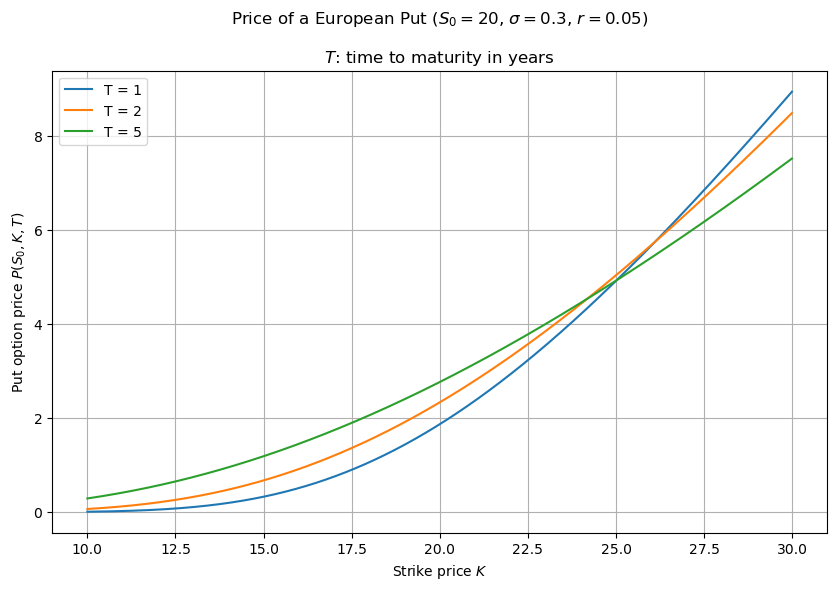

In [6]:
def black_scholes_eur_put(r: float, T: float, S0: float, sigma: float, K: Union[float, List[float], np.ndarray]) -> np.ndarray:
    # check conditions
    assert sigma > 0

    K = np.array([K]) if isinstance(K, float) else np.array(K)
    d1_vec = ( np.log( S0 / K ) + ( r + 0.5 * sigma**2 ) * T ) / ( sigma * T**0.5 )
    d2_vec = d1_vec - sigma * T**0.5
    N_d1_vec = norm.cdf(-d1_vec)
    N_d2_vec = norm.cdf(-d2_vec)
    put_price= K * np.exp((-1.0)*r*T) *N_d2_vec-N_d1_vec * S0
    return put_price

def black_scholes_eur_put_greeks(r: float, T: float, S0: float, sigma: float, K: Union[float, List[float], np.ndarray]) -> np.ndarray:
    # check conditions
    assert sigma > 0

    K = np.array([K]) if isinstance(K, float) else np.array(K)
    d1_vec = ( np.log( S0 / K ) + ( r + 0.5 * sigma**2 ) * T ) / ( sigma * T**0.5 )
    d2_vec = d1_vec - sigma * T**0.5
    N_d1_vec = norm.cdf(d1_vec)
    N_d2_vec = norm.cdf(d2_vec)

    #greeks
    gamma=norm.pdf(d1_vec)*(1/(S0*sigma*np.sqrt(T)))
    vega= S0 * norm.pdf(d1_vec)*np.sqrt(T)
    theta=-S0*norm.pdf(d1_vec)*(sigma/2*np.sqrt(T))+r*K*np.exp(-r*T)*norm.cdf(-d2_vec)
    rho=K*T*np.exp(-r*T)*norm.cdf(-d2_vec)
    delta=N_d1_vec-1
    return delta,gamma,theta,rho,vega

# Strike prices for which the option price is calculated
K_vec = np.arange(10, 30, 0.01)

# Time to maturities (in year fractions)
T_vec = [1.0, 2.0, 5.0]

prices_to_plot = []
for _T in T_vec:
    prices_to_plot.append(black_scholes_eur_put(r=0.05, T=_T, S0=20.0, sigma=0.3, K=K_vec))

plt.figure(figsize=(10, 6))

for put_price, T in zip(prices_to_plot, T_vec):
    plt.plot(K_vec, put_price, label=f"T = {int(T)}")

plt.title(
    'Price of a European Put ($S_0 = 20$, $\\sigma = 0.3$, $r = 0.05$)\n\n'
    '$T$: time to maturity in years'
)

plt.xlabel('Strike price $K$')
plt.ylabel('Put option price $P(S_0,K,T)$')

plt.legend()
plt.grid(True)
plt.show()



In [7]:
#put call paritas
r = 0.05
T = 1.0
S0 = 20.0
sigma = 0.3
K_vec = np.arange(10, 30, 0.1)

calls = black_scholes_eur_call(r, T, S0, sigma, K_vec)
puts = black_scholes_eur_put(r, T, S0, sigma, K_vec)


bal_oldal=calls-puts
jobb_oldal=S0 - K_vec * np.exp(-r * T)


diff =bal_oldal-jobb_oldal
print(diff)


[ 0.00000000e+00 -3.55271368e-15  1.77635684e-15  1.77635684e-15
 -1.77635684e-15  1.77635684e-15  0.00000000e+00 -1.77635684e-15
  1.77635684e-15  1.77635684e-15 -1.77635684e-15  0.00000000e+00
 -1.77635684e-15  1.77635684e-15  0.00000000e+00  1.77635684e-15
  0.00000000e+00  1.77635684e-15  0.00000000e+00  1.77635684e-15
  3.55271368e-15  1.77635684e-15  0.00000000e+00 -1.77635684e-15
  0.00000000e+00 -1.77635684e-15 -1.77635684e-15  0.00000000e+00
 -1.77635684e-15 -1.77635684e-15 -8.88178420e-16 -8.88178420e-16
 -1.77635684e-15 -1.77635684e-15 -1.77635684e-15 -1.77635684e-15
  1.77635684e-15 -8.88178420e-16  1.77635684e-15 -8.88178420e-16
  0.00000000e+00 -8.88178420e-16 -3.55271368e-15  1.77635684e-15
 -1.77635684e-15 -1.77635684e-15  0.00000000e+00  8.88178420e-16
 -1.77635684e-15  2.66453526e-15  0.00000000e+00 -3.55271368e-15
 -2.66453526e-15 -2.66453526e-15 -1.77635684e-15  1.77635684e-15
  0.00000000e+00  0.00000000e+00 -1.77635684e-15 -2.66453526e-15
 -1.77635684e-15  0.00000